# Product Review Intelligence System
### Aspect-Based Sentiment Analysis (ABSA)

**Customer Reviews → Candidate Aspects → Aspect Sentiment → Confidence → Dashboard**

## 1. Setup and Load ABSA Model

In [1]:
!pip -q install transformers torch spacy seaborn
!python -m spacy download en_core_web_sm -q

import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import spacy
import torch

from google.colab import files
from transformers import pipeline

nlp = spacy.load("en_core_web_sm")

MODEL_NAME = "yangheng/deberta-v3-base-absa-v1.1"
DEVICE = 0 if torch.cuda.is_available() else -1

absa_pipeline = pipeline(
    "text-classification",
    model=MODEL_NAME,
    tokenizer=MODEL_NAME,
    device=DEVICE
)

print("Device:", "GPU" if DEVICE == 0 else "CPU")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 69.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  738MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

...

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/18.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

Device: GPU


## 2. Load Reviews and Select a Project Sample

In [2]:
uploaded = files.upload()
file_name = next(f for f in uploaded if f.lower().endswith(".csv"))

df = pd.read_csv(file_name, low_memory=False, on_bad_lines="skip")
df = df[["review"]].dropna()

# Use a representative sample for the dashboard.
SAMPLE_SIZE = 1000
df = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=42).reset_index(drop=True)

print("Reviews selected:", len(df))
display(df.head())

Saving Flipkart_Reviews - Electronics.csv to Flipkart_Reviews - Electronics.csv
Reviews selected: 1000


,review
0,Its really amazing ... If u want a good sound ...
1,Product quality is poor. I replaced also but a...
2,This is an amazing product..I have used severa...
3,Bad experience ....after using just once for e...
4,O earphone just in Rs900 super quality value o...


## 3. Clean Review Text

In [3]:
def clean_text(text):
    text = re.sub(r"<[^>]+>|http\S+|www\S+", " ", str(text))
    text = re.sub(r"[^A-Za-z0-9\s!?.,'’-]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

df["clean_review"] = df["review"].apply(clean_text)
df = df[df["clean_review"].str.len() > 0].reset_index(drop=True)

print("Usable reviews:", len(df))

Usable reviews: 1000


## 4. Extract and Clean Candidate Product Aspects

In [4]:
# Domain aspects that are useful for electronics reviews.
DOMAIN_ASPECTS = {
    "battery", "battery life", "battery backup",
    "sound", "sound quality", "audio", "bass",
    "microphone", "call quality",
    "charging", "charging time", "fast charging",
    "camera", "camera quality", "picture", "picture quality",
    "display", "screen", "screen quality",
    "processor", "performance", "speed",
    "design", "build quality", "quality",
    "comfort", "fit",
    "heating", "temperature", "gaming",
    "price", "value", "delivery", "packaging", "service"
}

GENERIC_WORDS = {
    "i","me","my","we","us","our","you","your","he","she","it","they","them",
    "this","that","these","those","which","who",
    "thing","things","product","products","item","items","review","reviews",
    "customer","customers","people","person","one","ones","time","times",
    "day","days","year","years","way","ways",
    "mobile","phone","phones","device","devices",
    "headphone","headphones","earphone","earphones","earbud","earbuds",
    "point","purchase","experience","problem","issue","reason","money",
    "premium"
}

ATTRIBUTE_ONLY = {
    "premium", "excellent", "great", "good", "poor", "terrible",
    "beautiful", "vibrant", "attractive", "comfortable", "solid",
    "fast", "slow", "strong", "weak", "clear", "powerful"
}

def normalize_aspect_text(text):
    text = text.lower().strip()

    mapping = {
        "battery life": "battery",
        "battery backup": "battery",
        "battery performance": "battery",
        "battery drain": "battery",
        "battery drains": "battery",
        "sound quality": "sound",
        "audio quality": "sound",
        "call quality": "microphone",
        "microphone quality": "microphone",
        "mic": "microphone",
        "mics": "microphone",
        "charging time": "charging",
        "fast charging": "charging",
        "picture quality": "camera",
        "pictures": "camera",
        "screen": "display",
        "screen quality": "display",
        "speed": "performance",
        "appearance": "design",
        "looks": "design",
        "build": "build quality",
        "temperature": "heating"
    }

    return mapping.get(text, text)

def extract_aspects(doc):
    candidates = []

    # 1. Use noun chunks for normal product aspects.
    for chunk in doc.noun_chunks:
        tokens = [
            t for t in chunk
            if t.pos_ not in {"DET", "PRON"}
            and t.text.lower() not in {"very", "really", "just", "also", "too"}
        ]

        if not tokens:
            continue

        raw = " ".join(t.lemma_.lower() for t in tokens)

        # Exact useful domain phrase.
        if raw in DOMAIN_ASPECTS:
            candidates.append(normalize_aspect_text(raw))
            continue

        # Reject pronouns/generic terms.
        if any(w in GENERIC_WORDS for w in raw.split()):
            continue

        # Adjective + noun: "strong processor" -> processor.
        if len(tokens) == 2 and tokens[0].pos_ == "ADJ" and tokens[1].pos_ in {"NOUN", "PROPN"}:
            noun = tokens[1].lemma_.lower()
            if noun not in GENERIC_WORDS:
                candidates.append(normalize_aspect_text(noun))
            continue

        # Noun phrase: keep up to 3 nouns.
        if len(tokens) <= 3 and all(t.pos_ in {"NOUN", "PROPN"} for t in tokens):
            candidates.append(normalize_aspect_text(raw))
            continue

        # Single useful noun.
        if len(tokens) == 1 and tokens[0].pos_ in {"NOUN", "PROPN"}:
            candidates.append(normalize_aspect_text(tokens[0].lemma_.lower()))

    # 2. Catch useful adjective-based aspects:
    # "earbuds are comfortable" -> comfort
    # "device becomes hot" -> heating
    for token in doc:
        lemma = token.lemma_.lower()

        if token.pos_ == "ADJ":
            if lemma in {"comfortable", "comfort"}:
                candidates.append("comfort")
            elif lemma in {"hot", "heating", "warm"}:
                candidates.append("heating")

    # 3. Keep only useful product aspects.
    final = []
    for aspect in candidates:
        aspect = normalize_aspect_text(aspect)

        if aspect in GENERIC_WORDS or aspect in ATTRIBUTE_ONLY:
            continue

        # Remove vague single words.
        if aspect in {"quality", "call", "gaming"}:
            # quality can still be useful when explicitly tied to another
            # aspect, but don't report bare "quality".
            continue

        if aspect and aspect not in final:
            final.append(aspect)

    # Prefer specific domain aspects over generic candidates.
    return final

# Quick extraction test
test_review = (
    "The sound quality is excellent and the battery backup is great, "
    "but the microphone is poor and charging takes too long. "
    "The design looks premium and comfortable, while the performance becomes slow during gaming."
)

for sent in nlp(test_review).sents:
    print(sent.text)
    print("→", extract_aspects(sent))

The sound quality is excellent and the battery backup is great, but the microphone is poor and charging takes too long.
→ ['sound', 'battery', 'microphone']
The design looks premium and comfortable, while the performance becomes slow during gaming.
→ ['design', 'performance', 'comfort']


## 5. Create Aspect-Sentence Pairs

In [5]:
pairs = []

for review_id, doc in enumerate(
    nlp.pipe(df["clean_review"], batch_size=64)
):
    for sent in doc.sents:
        sentence = sent.text.strip()

        if len(sentence.split()) < 3:
            continue

        for aspect in extract_aspects(sent):
            pairs.append({
                "review_id": review_id,
                "sentence": sentence,
                "aspect": aspect
            })

pairs_df = pd.DataFrame(pairs)

print("Aspect-sentence pairs:", len(pairs_df))
display(pairs_df.head(15))

Aspect-sentence pairs: 2410


,review_id,sentence,aspect
0,0,If u want a good sound quality under normal bu...,budget
1,2,I have used several earphones in this price ca...,price
2,3,Bad experience ....after using just once for e...,exercise
3,3,Bad experience ....after using just once for e...,function key
4,3,I don't know how they say it's water or sweat ...,water
5,3,I don't know how they say it's water or sweat ...,sweat proof
6,5,It’s design and quality is very good worth buy...,design
7,8,"Comparison Between Boat 225 , Realme Buds 2, S...",boat
8,8,"Comparison Between Boat 225 , Realme Buds 2, S...",realme buds
9,8,"Comparison Between Boat 225 , Realme Buds 2, S...",sennheiser cx


## 6. Predict Aspect Sentiment and Confidence

In [6]:
model_inputs = [
    {"text": row.sentence, "text_pair": row.aspect}
    for row in pairs_df.itertuples()
]

predictions = absa_pipeline(
    model_inputs,
    batch_size=16,
    truncation=True
)

pairs_df["sentiment"] = [p["label"] for p in predictions]
pairs_df["confidence"] = [
    round(float(p["score"]), 3) for p in predictions
]

display(
    pairs_df[["aspect", "sentiment", "confidence", "sentence"]].head(15)
)

,aspect,sentiment,confidence,sentence
0,budget,Positive,0.727,If u want a good sound quality under normal bu...
1,price,Positive,0.530,I have used several earphones in this price ca...
2,exercise,Neutral,0.993,Bad experience ....after using just once for e...
3,function key,Negative,0.998,Bad experience ....after using just once for e...
4,water,Neutral,0.871,I don't know how they say it's water or sweat ...
5,sweat proof,Negative,0.970,I don't know how they say it's water or sweat ...
6,design,Positive,0.999,It’s design and quality is very good worth buy...
7,boat,Positive,0.725,"Comparison Between Boat 225 , Realme Buds 2, S..."
8,realme buds,Positive,0.615,"Comparison Between Boat 225 , Realme Buds 2, S..."
9,sennheiser cx,Neutral,0.588,"Comparison Between Boat 225 , Realme Buds 2, S..."


## 7. Test the System on a New Customer Review

In [12]:
def analyze_new_review(review):
    review = clean_text(review)
    rows = []

    for sent in nlp(review).sents:
        sentence = sent.text.strip()

        if len(sentence.split()) < 3:
            continue

        for aspect in extract_aspects(sent):
            rows.append({
                "sentence": sentence,
                "aspect": aspect
            })

    if not rows:
        return pd.DataFrame(columns=["aspect", "sentiment", "confidence"])

    result = pd.DataFrame(rows)

    inputs = [
        {"text": row.sentence, "text_pair": row.aspect}
        for row in result.itertuples()
    ]

    predictions = absa_pipeline(
        inputs,
        batch_size=16,
        truncation=True
    )

    result["sentiment"] = [p["label"] for p in predictions]
    result["confidence"] = [
        round(float(p["score"]), 3) for p in predictions
    ]

    return result[["aspect", "sentiment", "confidence"]]

new_review = input("Enter a customer review: ")
display(analyze_new_review(new_review))

Enter a customer review: I bought these wireless earbuds a few days ago and I'm quite happy with them. The sound is clear and the bass is good, but the battery life could be better. They are comfortable to wear for long periods and the design looks nice. However, the microphone isn't very clear during phone calls


,aspect,sentiment,confidence
0,sound,Positive,0.998
1,bass,Positive,0.998
2,battery,Negative,0.934
3,period,Positive,0.960
4,design,Positive,0.997
5,comfort,Positive,0.997
6,microphone,Negative,0.995


## 8. Aspect-Level Summary

In [8]:
summary = (
    pairs_df
    .groupby(["aspect", "sentiment"])
    .size()
    .unstack(fill_value=0)
)

for col in ["Positive", "Negative", "Neutral"]:
    if col not in summary.columns:
        summary[col] = 0

summary["Total"] = summary[["Positive", "Negative", "Neutral"]].sum(axis=1)
summary["Positive %"] = (summary["Positive"] / summary["Total"] * 100).round(1)
summary["Negative %"] = (summary["Negative"] / summary["Total"] * 100).round(1)

summary = summary.sort_values("Total", ascending=False)

display(summary.head(15))

sentiment,Negative,Neutral,Positive,Total,Positive %,Negative %
aspect,,,,,,
bass,63,13,123,199,61.8,31.7
sound,25,8,131,164,79.9,15.2
price,2,9,66,77,85.7,2.6
battery,8,7,49,64,76.6,12.5
ear,15,9,17,41,41.5,36.6
price range,2,4,34,40,85.0,5.0
design,5,1,34,40,85.0,12.5
boat,4,19,12,35,34.3,11.4
build quality,2,0,33,35,94.3,5.7


## 9. Positive and Negative Aspect Visualization

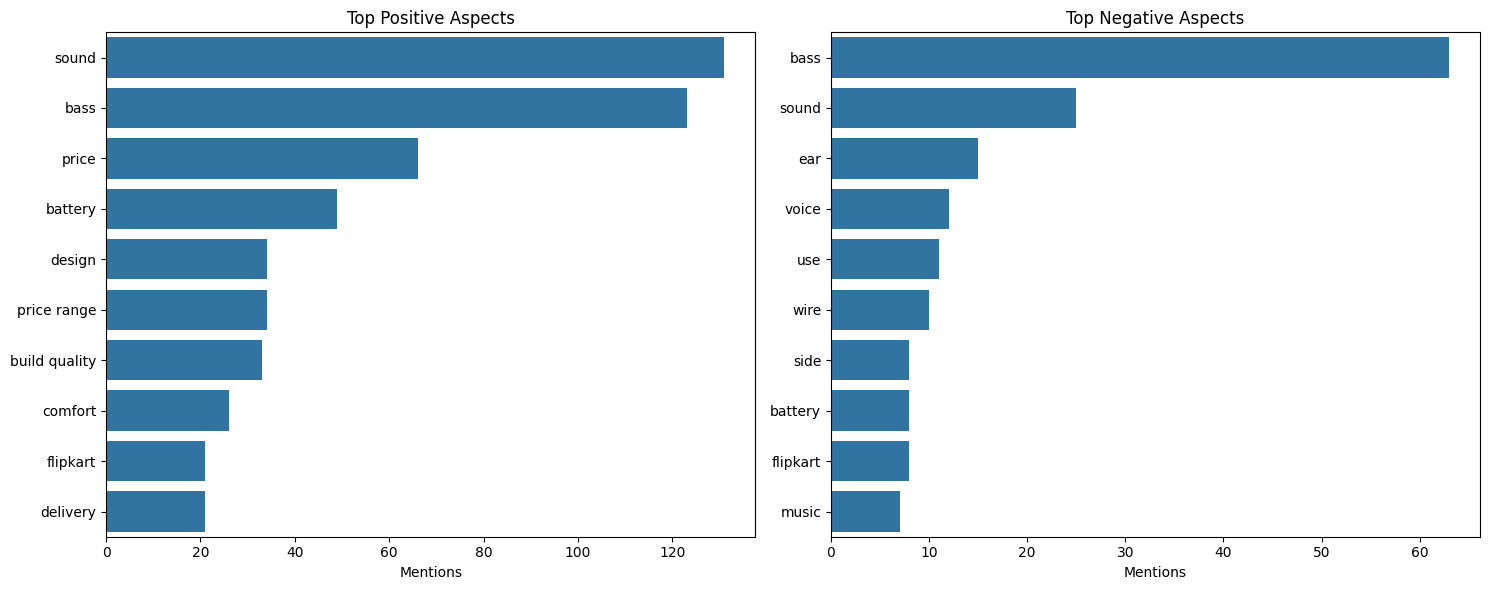

In [9]:
positive = (
    pairs_df[pairs_df["sentiment"] == "Positive"]["aspect"]
    .value_counts()
    .head(10)
)

negative = (
    pairs_df[pairs_df["sentiment"] == "Negative"]["aspect"]
    .value_counts()
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=positive.values, y=positive.index, ax=axes[0])
axes[0].set_title("Top Positive Aspects")
axes[0].set_xlabel("Mentions")
axes[0].set_ylabel("")

sns.barplot(x=negative.values, y=negative.index, ax=axes[1])
axes[1].set_title("Top Negative Aspects")
axes[1].set_xlabel("Mentions")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 10. Product Review Intelligence Dashboard

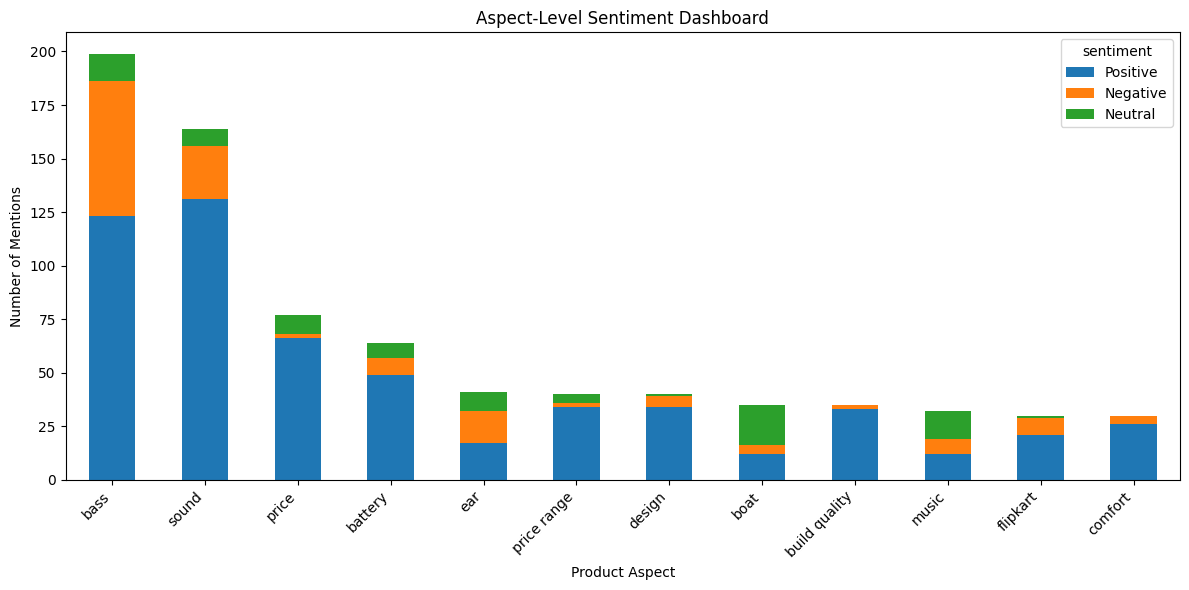

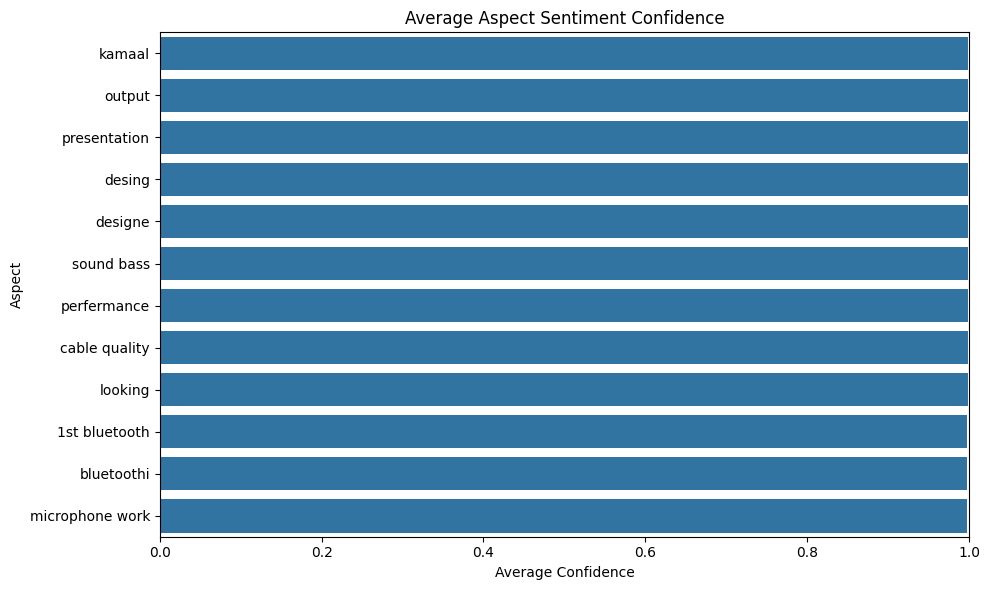

In [10]:
dashboard = summary.head(12)[["Positive", "Negative", "Neutral"]]

dashboard.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Aspect-Level Sentiment Dashboard")
plt.xlabel("Product Aspect")
plt.ylabel("Number of Mentions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

confidence = (
    pairs_df.groupby("aspect")["confidence"]
    .mean()
    .sort_values(ascending=False)
    .head(12)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=confidence.values, y=confidence.index)
plt.xlim(0, 1)
plt.xlabel("Average Confidence")
plt.ylabel("Aspect")
plt.title("Average Aspect Sentiment Confidence")
plt.tight_layout()
plt.show()